Using device: cuda
Classes: ['NORMAL', 'PNEUMONIA']
Num test samples: 624

Evaluating Cecilia...
              precision    recall  f1-score   support

      NORMAL     0.9702    0.6966    0.8109       234
   PNEUMONIA     0.8443    0.9872    0.9102       390

    accuracy                         0.8782       624
   macro avg     0.9073    0.8419    0.8606       624
weighted avg     0.8915    0.8782    0.8730       624

Confusion matrix:
[[163  71]
 [  5 385]]

Evaluating Cecilia_SelfAttention...
              precision    recall  f1-score   support

      NORMAL     0.9135    0.4060    0.5621       234
   PNEUMONIA     0.7327    0.9769    0.8374       390

    accuracy                         0.7628       624
   macro avg     0.8231    0.6915    0.6997       624
weighted avg     0.8005    0.7628    0.7342       624

Confusion matrix:
[[ 95 139]
 [  9 381]]

Metrics summary:
                   model  accuracy  precision_macro  recall_macro  f1_macro  \
0                Cecilia  0.87820

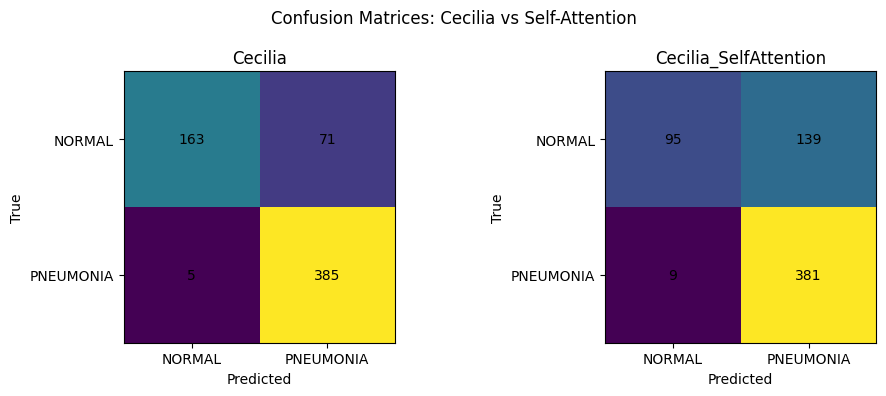

Saved confusion matrix figure to: results/cecilia_vs_self_attn\confusion_matrices_cecilia_vs_self_attn.png


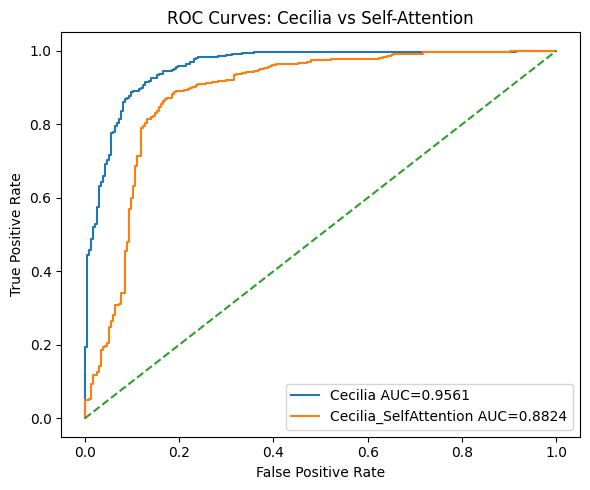

Saved ROC figure to: results/cecilia_vs_self_attn\roc_cecilia_vs_self_attn.png


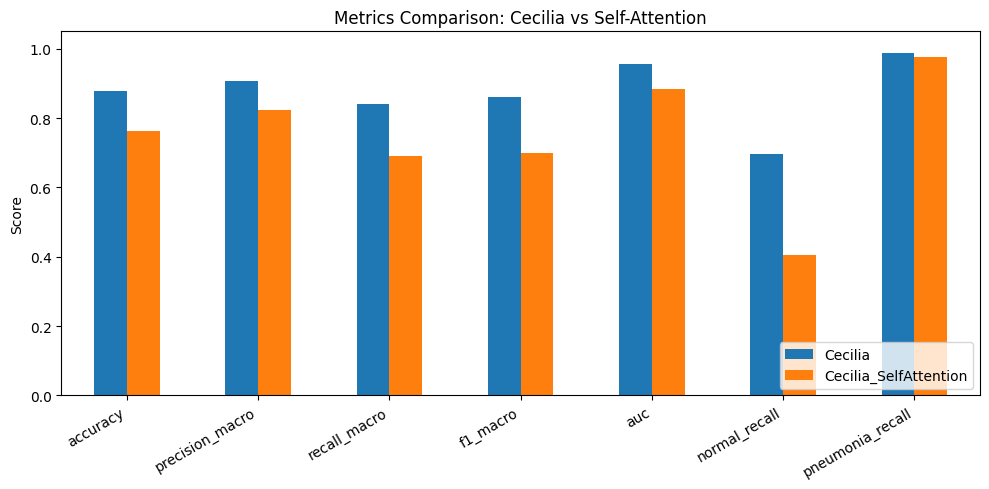

Saved metrics bar figure to: results/cecilia_vs_self_attn\metrics_bar_cecilia_vs_self_attn.png
Saved threshold sweep to: results/cecilia_vs_self_attn\threshold_sweep_cecilia_vs_self_attn.csv


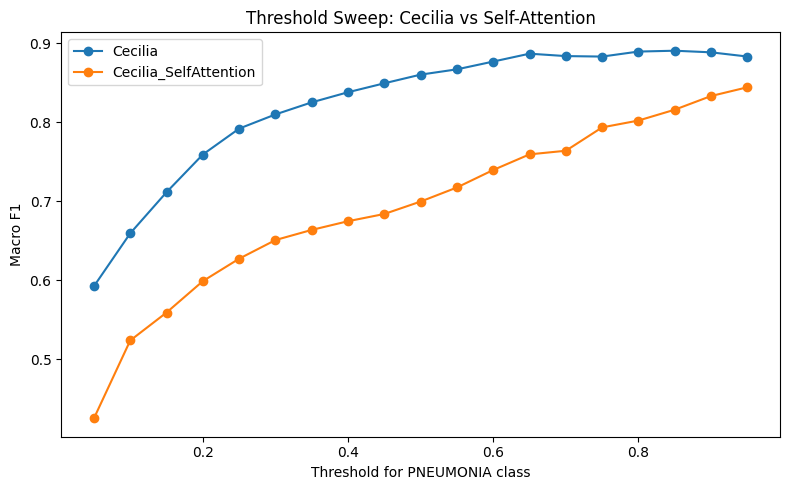

Saved threshold sweep figure to: results/cecilia_vs_self_attn\threshold_sweep_f1_cecilia_vs_self_attn.png

All comparison results saved in:
results/cecilia_vs_self_attn


In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)


# ============================
# 路径配置
# ============================
data_root = "./chest_xray_split"
test_root = "./chest_xray/chest_xray/test"

cecilia_weight = "checkpoints/best_cecilia.pth"
self_attn_weight = "checkpoints/best_cecilia_self_attn.pth"

output_dir = "results/cecilia_vs_self_attn"
os.makedirs(output_dir, exist_ok=True)

batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================
# 数据预处理
# ============================
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = ImageFolder(test_root, transform=val_test_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

class_names = test_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Num test samples:", len(test_dataset))


# ============================
# 原始 Cecilia
# ============================
class Cecilia(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)


# ============================
# Self-Attention 模块
# ============================
class SelfAttention2D(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        hidden_channels = in_channels // 8

        self.query = nn.Conv2d(in_channels, hidden_channels, kernel_size=1)
        self.key = nn.Conv2d(in_channels, hidden_channels, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)

        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.shape
        N = H * W

        q = self.query(x).view(B, -1, N).permute(0, 2, 1)
        k = self.key(x).view(B, -1, N)
        v = self.value(x).view(B, C, N)

        attn = torch.bmm(q, k)
        attn = attn / (q.shape[-1] ** 0.5)
        attn = F.softmax(attn, dim=-1)

        out = torch.bmm(v, attn.permute(0, 2, 1))
        out = out.view(B, C, H, W)

        return self.gamma * out + x


# ============================
# Cecilia + Self-Attention
# ============================
class CeciliaSelfAttention(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            SelfAttention2D(64)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ============================
# 加载模型
# ============================
def load_model(model, weight_path):
    if not os.path.exists(weight_path):
        raise FileNotFoundError(f"找不到权重文件: {weight_path}")

    state_dict = torch.load(weight_path, map_location=device)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model


models = {
    "Cecilia": load_model(Cecilia(num_classes), cecilia_weight),
    "Cecilia_SelfAttention": load_model(CeciliaSelfAttention(num_classes), self_attn_weight)
}


# ============================
# 收集预测结果
# ============================
def collect_predictions(model, loader):
    all_labels = []
    all_preds = []
    all_probs = []

    model.eval()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.long().to(device)

            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )


# ============================
# 计算指标
# ============================
results = {}
metrics_rows = []

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")

    y_true, y_pred, y_prob = collect_predictions(model, test_loader)

    acc = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    cm = confusion_matrix(y_true, y_pred)

    normal_recall = recall_score(y_true, y_pred, labels=[0], average="macro", zero_division=0)
    pneumonia_recall = recall_score(y_true, y_pred, labels=[1], average="macro", zero_division=0)

    results[model_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "cm": cm
    }

    metrics_rows.append({
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "auc": auc,
        "normal_recall": normal_recall,
        "pneumonia_recall": pneumonia_recall
    })

    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    print("Confusion matrix:")
    print(cm)


metrics_df = pd.DataFrame(metrics_rows)
metrics_csv_path = os.path.join(output_dir, "metrics_cecilia_vs_self_attn.csv")
metrics_df.to_csv(metrics_csv_path, index=False)

print("\nMetrics summary:")
print(metrics_df)
print(f"\nSaved metrics to: {metrics_csv_path}")


# ============================
# 保存混淆矩阵图
# ============================
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))

if len(models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models.keys()):
    cm = results[model_name]["cm"]

    im = ax.imshow(cm)
    ax.set_title(model_name)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

fig.suptitle("Confusion Matrices: Cecilia vs Self-Attention")
plt.tight_layout()

cm_path = os.path.join(output_dir, "confusion_matrices_cecilia_vs_self_attn.png")
plt.savefig(cm_path, dpi=300)
plt.show()

print(f"Saved confusion matrix figure to: {cm_path}")


# ============================
# 保存 ROC 曲线
# ============================
plt.figure(figsize=(6, 5))

for model_name in models.keys():
    y_true = results[model_name]["y_true"]
    y_prob = results[model_name]["y_prob"]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.plot(fpr, tpr, label=f"{model_name} AUC={auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Cecilia vs Self-Attention")
plt.legend()
plt.tight_layout()

roc_path = os.path.join(output_dir, "roc_cecilia_vs_self_attn.png")
plt.savefig(roc_path, dpi=300)
plt.show()

print(f"Saved ROC figure to: {roc_path}")


# ============================
# 保存指标柱状图
# ============================
plot_metrics = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "auc",
    "normal_recall",
    "pneumonia_recall"
]

metrics_df_plot = metrics_df.set_index("model")[plot_metrics]

ax = metrics_df_plot.T.plot(kind="bar", figsize=(10, 5))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Metrics Comparison: Cecilia vs Self-Attention")
ax.legend(loc="lower right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

bar_path = os.path.join(output_dir, "metrics_bar_cecilia_vs_self_attn.png")
plt.savefig(bar_path, dpi=300)
plt.show()

print(f"Saved metrics bar figure to: {bar_path}")


# ============================
# threshold sweep
# ============================
threshold_rows = []

thresholds = np.arange(0.05, 0.96, 0.05)

for model_name in models.keys():
    y_true = results[model_name]["y_true"]
    y_prob = results[model_name]["y_prob"]

    for th in thresholds:
        y_pred_th = (y_prob >= th).astype(int)

        threshold_rows.append({
            "model": model_name,
            "threshold": th,
            "accuracy": accuracy_score(y_true, y_pred_th),
            "precision_macro": precision_score(y_true, y_pred_th, average="macro", zero_division=0),
            "recall_macro": recall_score(y_true, y_pred_th, average="macro", zero_division=0),
            "f1_macro": f1_score(y_true, y_pred_th, average="macro", zero_division=0),
            "normal_recall": recall_score(y_true, y_pred_th, labels=[0], average="macro", zero_division=0),
            "pneumonia_recall": recall_score(y_true, y_pred_th, labels=[1], average="macro", zero_division=0),
        })

threshold_df = pd.DataFrame(threshold_rows)

threshold_csv_path = os.path.join(output_dir, "threshold_sweep_cecilia_vs_self_attn.csv")
threshold_df.to_csv(threshold_csv_path, index=False)

print(f"Saved threshold sweep to: {threshold_csv_path}")


# ============================
# threshold sweep 图
# ============================
plt.figure(figsize=(8, 5))

for model_name in models.keys():
    temp = threshold_df[threshold_df["model"] == model_name]
    plt.plot(temp["threshold"], temp["f1_macro"], marker="o", label=model_name)

plt.xlabel("Threshold for PNEUMONIA class")
plt.ylabel("Macro F1")
plt.title("Threshold Sweep: Cecilia vs Self-Attention")
plt.legend()
plt.tight_layout()

threshold_fig_path = os.path.join(output_dir, "threshold_sweep_f1_cecilia_vs_self_attn.png")
plt.savefig(threshold_fig_path, dpi=300)
plt.show()

print(f"Saved threshold sweep figure to: {threshold_fig_path}")


print("\nAll comparison results saved in:")
print(output_dir)